In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Rectangle
import seaborn as sns

from scipy import stats

from sklearn.tree import DecisionTreeClassifier, plot_tree

from utils.Flow import analysis_folder as data_folder
from utils.WeightedCheckUtil import *
import os
import glob

# Load and show statistics

In [2]:
pk1_file_path = glob.glob(os.path.join(data_folder, '*_net_results.pk1'))

result_df = pd.concat(
    [pd.read_pickle(f) for f in pk1_file_path],
    ignore_index=True
)

result_df['hcs_std'] = result_df['hcs_std'].astype(float)
result_df['hcs_mean'] = result_df['hcs_mean'].astype(float)

In [3]:
display(result_df)

,name,is_mst,modularity,small_world,hcs_std,hcs_mean,assortativity,variance,fit_pl,fit_exp,wmse_pl,wmse_exp,pl_ex_ratio
0,facebook_wall,False,0.727727,{'clustering_coefficient': 0.08509450365234017...,10.312789,10.244141,0.051319,0.000593,-4.163173,-0.416070,0.025277,0.002195,11.517098
1,facebook_wall,True,0.979930,"{'clustering_coefficient': 0.0, 'edge_num': 43...",0.506006,0.724716,-0.106666,0.001667,-2.310650,-0.095987,0.003981,0.006309,0.631051
2,digg_reply,False,0.426654,{'clustering_coefficient': 0.00559831257463109...,7.924628,7.490842,0.008498,0.000630,-4.551218,-0.574228,0.021816,0.002915,7.484566
3,digg_reply,True,0.986783,"{'clustering_coefficient': 0.0, 'edge_num': 29...",0.360835,0.610657,-0.111788,0.001939,-2.317374,-0.097214,0.004517,0.005087,0.888027
4,foldoc,False,0.621286,{'clustering_coefficient': 0.11319453494938964...,4.257009,5.797251,0.014467,0.000762,-4.648211,-0.796501,0.002020,0.011900,0.169779
...,...,...,...,...,...,...,...,...,...,...,...,...,...
115,wikipedia_link/az,False,0.756008,{'clustering_coefficient': 0.08250319561892774...,33.862275,72.948477,0.058151,0.000133,-5.654843,-0.862069,0.007116,0.017469,0.407342
116,pokec,False,0.719958,{'clustering_coefficient': 0.04682115528737266...,24.901976,29.680813,0.001638,0.000019,-6.168973,-0.701608,0.037833,0.015966,2.369523
117,wikipedia_growth,False,0.554557,{'clustering_coefficient': 0.00308910857701705...,75.895559,65.198387,-0.000325,0.000009,-6.488468,-0.855800,0.004468,0.068241,0.065473
118,livejournal,False,0.769351,{'clustering_coefficient': 0.11790120494382822...,65.290281,33.057829,0.019019,0.000024,-6.112160,-0.616796,0.069315,0.002362,29.345187


In [4]:
df = result_df.copy()
df = df[~df['is_mst']]
len(df)

91

In [5]:
mst_df = result_df.copy()
mst_df = mst_df[mst_df['is_mst']]
len(mst_df)

29

### Properties preparation

In [6]:
def tree_plot(tree, feature_columns, figsize=(16, 8)):
    plt.figure(figsize=figsize)
    plot_tree(
        tree,
        feature_names=feature_columns,
        class_names=['Not Fractal', 'Fractal'],
        filled=True,
        rounded=True,
        fontsize=12
    )
    plt.show()

In [7]:
df['CC_norm'] = df['small_world'].str.get('clustering_coefficient_normalized')
df['L_norm'] = df['small_world'].str.get('l_normalized')
df['V'] = df['small_world'].str.get('vertice_num')
df['E'] = df['small_world'].str.get('edge_num')
df['d_f'] = df['fit_pl'] * -1

mst_df['CC_norm'] = mst_df['small_world'].str.get('clustering_coefficient_normalized')
mst_df['L_norm'] = mst_df['small_world'].str.get('l_normalized')
mst_df['V'] = mst_df['small_world'].str.get('vertice_num')
mst_df['E'] = mst_df['small_world'].str.get('edge_num')
mst_df['d_f'] = mst_df['fit_pl'] * -1

### Statistics

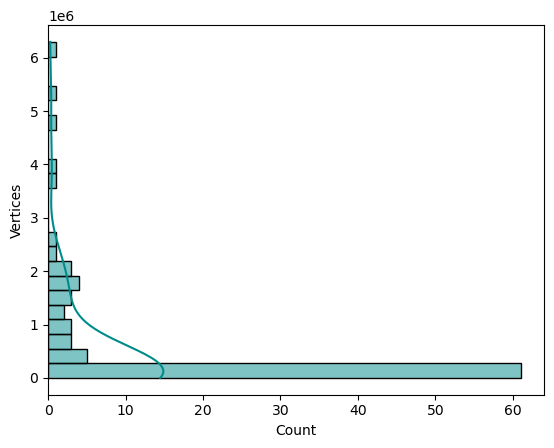

In [8]:
sns.histplot(data=df, y='V', kde=True, color='darkcyan')

# plt.title('Distribution of the Vertices')
# plt.xscale('log')
plt.ylabel('Vertices')
plt.show()

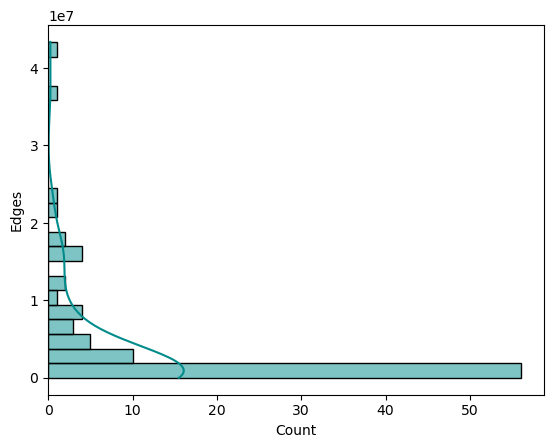

In [9]:
sns.histplot(data=df, y='E', kde=True, color='darkcyan')

# plt.title('Distribution of the Edges')
# plt.xscale('log')
plt.ylabel("Edges")
plt.show()

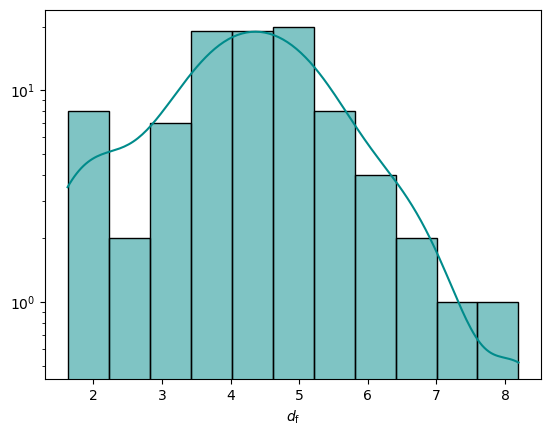

In [10]:
sns.histplot(data=df, x='d_f', kde=True, color='darkcyan')

# plt.title('Distribution of the Fractality dimension')
plt.yscale('log')
plt.ylabel('')
plt.xlabel('$d_\mathrm{f}$')
plt.show()

In [11]:
df[df['pl_ex_ratio']>100]

,name,is_mst,modularity,small_world,hcs_std,hcs_mean,assortativity,variance,fit_pl,fit_exp,wmse_pl,wmse_exp,pl_ex_ratio,CC_norm,L_norm,V,E,d_f
107,twitter,False,0.687918,{'clustering_coefficient': 0.00061262722552796...,11.119289,14.971752,-0.058327,0.000116,-4.82384,-0.862904,0.016375,0.000024,669.629611,79.465126,0.45132,465017,833540,4.82384


In [12]:
ns_dataset_weighting = pd.read_csv('network_info_community.csv')
ns_dataset_weighting.head()

,Unnamed: 0,average_degree,degree_assortativity,degree_std_dev,diameter,edge_properties,edge_reciprocity,global_clustering,hashimoto_radius,is_bipartite,...,mixing_time,num_edges,num_vertices,transition_gap,vertex_properties,name,tags,is_weighted,ds_name,community_label
0,85,6.984413,-0.016419,46.241795,16,[],0.537030,0.036263,109.991372,False,...,78.338610,1398063,200169,0.987316,"[['name', 'int32_t'], ['_pos', 'vector<double>']]",academia_edu,"['Social', 'Online', 'Unweighted']",Unweighted,academia_edu,Social
1,88,4.711275,-0.002543,5.919191,38,[],0.542702,0.310868,17.803235,False,...,3944.332763,1234877,262111,0.999747,"[['_pos', 'vector<double>']]",amazon_copurchases/302,"['Economic', 'Commerce', 'Unweighted']",Unweighted,amazon_copurchases,Economic
2,89,7.986584,-0.017233,15.834028,20,[],0.531534,0.248231,35.027683,False,...,895.794973,3200440,400727,0.998884,"[['_pos', 'vector<double>']]",amazon_copurchases/312,"['Economic', 'Commerce', 'Unweighted']",Unweighted,amazon_copurchases,Economic
3,90,8.182666,-0.013417,16.297625,22,[],0.546580,0.251219,40.356201,False,...,1805.088792,3356824,410236,0.999446,"[['_pos', 'vector<double>']]",amazon_copurchases/505,"['Economic', 'Commerce', 'Unweighted']",Unweighted,amazon_copurchases,Economic
4,91,8.397220,-0.013843,16.145707,25,[],0.557350,0.256012,40.310977,False,...,3656.500797,3387388,403394,0.999727,"[['_pos', 'vector<double>']]",amazon_copurchases/601,"['Economic', 'Commerce', 'Unweighted']",Unweighted,amazon_copurchases,Economic


In [13]:
df_community_merged = pd.merge(
    df,
    ns_dataset_weighting[['name', 'community_label', 'is_weighted']],
    on='name',
    how='left'
)

display(df_community_merged.head())

print(df_community_merged['community_label'].isna().sum())
print(df_community_merged['is_weighted'].isna().sum())

,name,is_mst,modularity,small_world,hcs_std,hcs_mean,assortativity,variance,fit_pl,fit_exp,wmse_pl,wmse_exp,pl_ex_ratio,CC_norm,L_norm,V,E,d_f,community_label,is_weighted
0,facebook_wall,False,0.727727,{'clustering_coefficient': 0.08509450365234017...,10.312789,10.244141,0.051319,0.000593,-4.163173,-0.416070,0.025277,0.002195,11.517098,430.045456,1.081986,43953,191128,4.163173,Social,Unweighted
1,digg_reply,False,0.426654,{'clustering_coefficient': 0.00559831257463109...,7.924628,7.490842,0.008498,0.000630,-4.551218,-0.574228,0.021816,0.002915,7.484566,28.653180,0.774563,29652,85891,4.551218,Social,Unweighted
2,foldoc,False,0.621286,{'clustering_coefficient': 0.11319453494938964...,4.257009,5.797251,0.014467,0.000762,-4.648211,-0.796501,0.002020,0.011900,0.169779,110.365247,0.990760,13356,91471,4.648211,Academic,Weighted
3,fly_hemibrain,False,0.666685,"{'clustering_coefficient': 0.2065895378429164,...",73.534851,97.340708,0.001335,0.000031,-3.532330,-0.688233,0.000691,0.014107,0.048971,16.844198,1.147799,21739,2897925,3.532330,Biological,Weighted
4,lkml_reply,False,0.389683,{'clustering_coefficient': 0.10560275777994876...,73.438830,47.812534,0.043921,0.000532,-2.417050,-0.097301,0.002439,0.014636,0.166646,195.784731,1.281236,24567,162762,2.417050,Technological,Unweighted


0
0


In [14]:
def plot_tag_pie_chart(
    column: pd.Series,
    figAx: tuple,
    title='Distribution',
    pct='%1.1f%%',
    label_filter=lambda pct: pct > 1,
    colors=None
):
    fig, ax = figAx
    
    value_counts = column.value_counts()

    percentages = value_counts / value_counts.sum() * 100

    # Create the pie chart
    _, texts, _ = ax.pie(value_counts.values.tolist(), labels=value_counts.index.tolist(
    ), autopct=pct, startangle=90, pctdistance=0.8, colors=colors)

    # Filters labes based on provided filter function
    if label_filter != None:
        for i, pct in enumerate(percentages):
            if label_filter(pct):
                texts[i].set_visible(True)
            else:
                texts[i].set_visible(False)

    ax.legend(labels=value_counts.index.tolist(),
              loc='best', bbox_to_anchor=(1, 0.5))
    fig.suptitle(title)
    plt.show()

In [15]:
def create_colors(length, palette_name='viridis'):
    cmap = plt.get_cmap(palette_name)
    return cmap(np.linspace(0,10), length)

In [16]:
df_community_merged['community_label'].value_counts()

community_label
Social           49
Academic         22
Technological     8
Biological        5
Transport         4
Economic          3
Name: count, dtype: int64

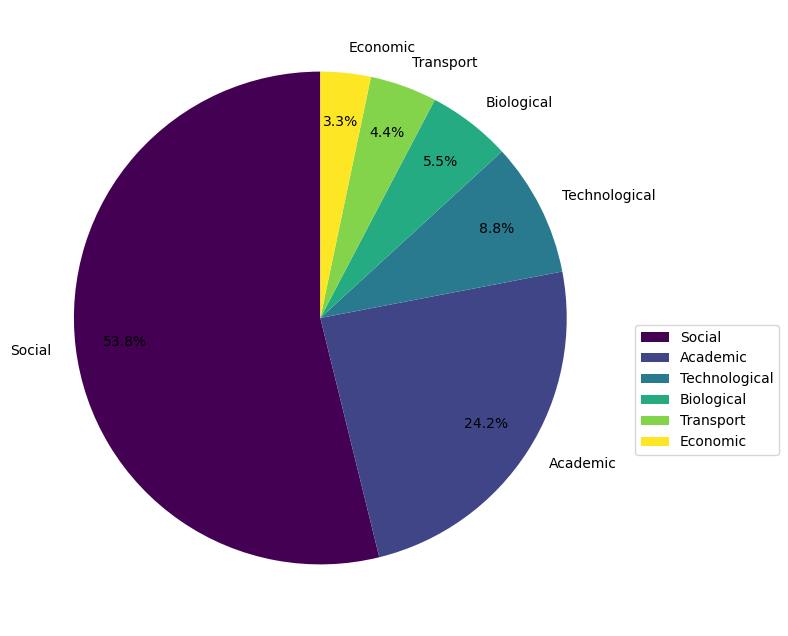

In [17]:
plot_tag_pie_chart(
    column=df_community_merged['community_label'],
    figAx=plt.subplots(figsize=(8, 8)),
    # title='Community label distribution',
    title='',
    colors=create_colors(len(df_community_merged['community_label'].value_counts()), 'viridis')
)

In [18]:
def barplot_with_percent(df, column_name, color_palette, title, xlabel, ylabel, horizontal = True, order = None):
    if horizontal:
        ax = sns.countplot(
            data=df, 
            y=column_name, 
            hue=column_name,
            palette=color_palette,
            order=order,
            legend=False 
        )
    else:
        ax = sns.countplot(
            data=df, 
            x=column_name, 
            hue=column_name,
            palette=color_palette,
            order=order,
            legend=False 
        )

    for container in ax.containers:
        percentages = [f'{100 * v / len(df):.1f}%' if v > 0 else '' for v in container.datavalues]
        
        ax.bar_label(container, labels=percentages, padding=3)

    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)

    if(horizontal):
        plt.xlim(0, ax.get_xlim()[1] * 1.15)
    else: 
        plt.ylim(0, ax.get_ylim()[1] * 1.15)

    plt.show()

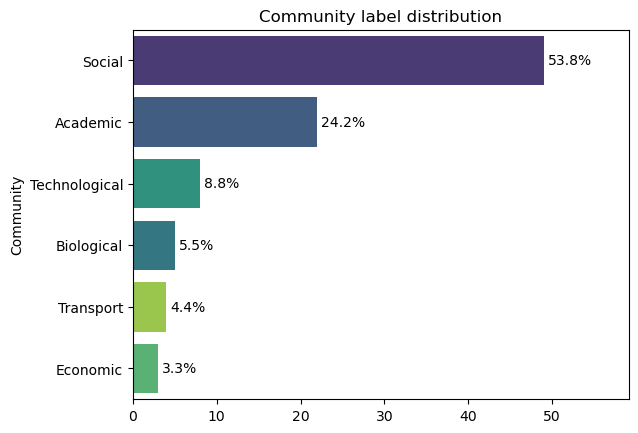

In [19]:
barplot_with_percent(
    df_community_merged,
    'community_label',
    'viridis',
    'Community label distribution',
    '',
    'Community',
    order=df_community_merged['community_label'].value_counts().index
)

In [20]:
mst_community_merged = pd.merge(
    mst_df,
    ns_dataset_weighting[['name', 'community_label', 'is_weighted']],
    on='name',
    how='left'
)

display(mst_community_merged.head())

print(mst_community_merged['community_label'].isna().sum())
print(mst_community_merged['is_weighted'].isna().sum())

,name,is_mst,modularity,small_world,hcs_std,hcs_mean,assortativity,variance,fit_pl,fit_exp,wmse_pl,wmse_exp,pl_ex_ratio,CC_norm,L_norm,V,E,d_f,community_label,is_weighted
0,facebook_wall,True,0.979930,"{'clustering_coefficient': 0.0, 'edge_num': 43...",0.506006,0.724716,-0.106666,0.001667,-2.310650,-0.095987,0.003981,0.006309,0.631051,0.0,2.727977,43953,43952,2.310650,Social,Unweighted
1,digg_reply,True,0.986783,"{'clustering_coefficient': 0.0, 'edge_num': 29...",0.360835,0.610657,-0.111788,0.001939,-2.317374,-0.097214,0.004517,0.005087,0.888027,0.0,2.138691,29652,29651,2.317374,Social,Unweighted
2,foldoc,True,0.978898,"{'clustering_coefficient': 0.0, 'edge_num': 13...",0.441379,0.368421,-0.057235,0.004022,-1.512681,-0.062461,0.000857,0.002593,0.330621,0.0,2.837074,13356,13355,1.512681,Academic,Weighted
3,fly_hemibrain,True,0.951208,"{'clustering_coefficient': 0.0, 'edge_num': 21...",0.259259,0.799403,-0.196768,0.001970,-2.142477,-0.086064,0.001622,0.010887,0.149016,0.0,1.577358,21739,21738,2.142477,Biological,Weighted
4,lkml_reply,True,0.873321,"{'clustering_coefficient': 0.0, 'edge_num': 24...",0.917582,0.784099,-0.085442,0.002333,-2.037942,-0.084315,0.002169,0.006095,0.355913,0.0,0.889875,24567,24566,2.037942,Technological,Unweighted


0
0


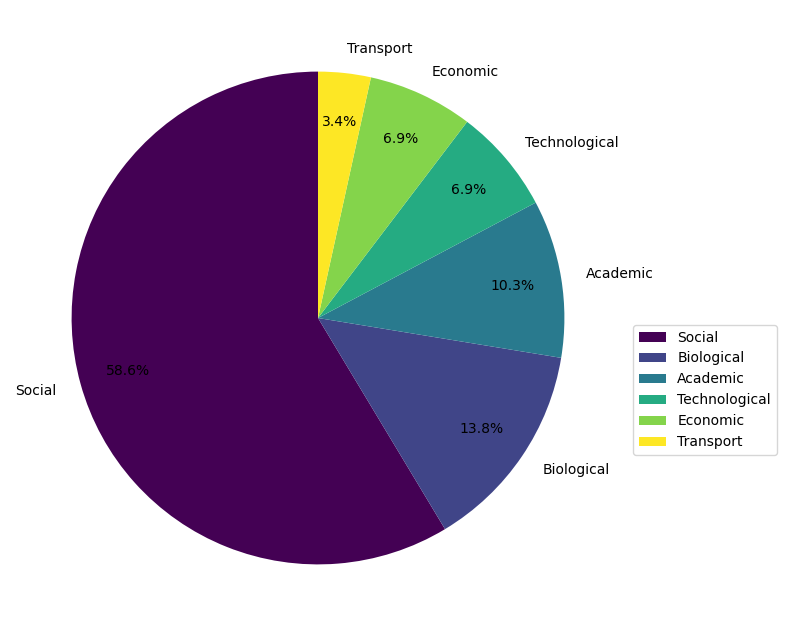

In [21]:
plot_tag_pie_chart(
    column=mst_community_merged['community_label'],
    figAx=plt.subplots(figsize=(8, 8)),
    # title='Community label distribution across MSTs',
    title='',
    colors=create_colors(len(mst_community_merged['community_label'].value_counts()), 'viridis')
)

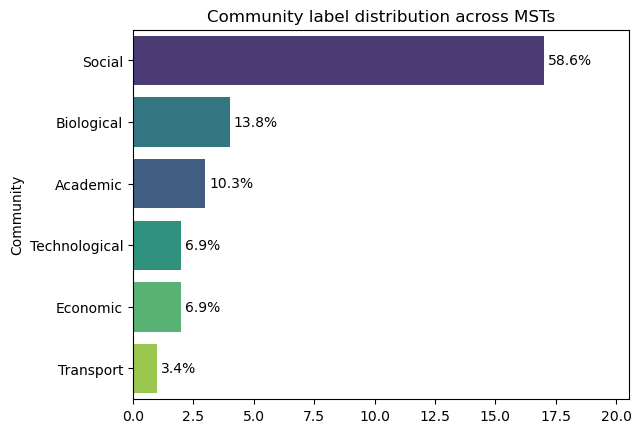

In [22]:
barplot_with_percent(
    mst_community_merged, 
    'community_label',
    'viridis',
    'Community label distribution across MSTs',
    '',
    'Community',
    order=mst_community_merged['community_label'].value_counts().index
)

## Analysis

In [23]:
D_F_THRESHOLD = 3.0
ERROR_RATIO_THRESHOLD = 1.0

CC_NORM_THRESHOLD = 10.0
L_NORM_LOW = 0.5
L_NORM_HIGH = 2.0

In [24]:
feature_cols = ['CC_norm', 'L_norm', 'modularity', 'hcs_mean', 'assortativity']
target_col_clas = 'is_fractal'

In [25]:
def add_is_fractal(to):
    to.loc[:, 'is_fractal'] = (to['pl_ex_ratio'] < ERROR_RATIO_THRESHOLD) & (to['d_f'] <= D_F_THRESHOLD)

In [26]:
add_is_fractal(to=df)

add_is_fractal(to=mst_df)

# RQ1: Coexistence of small-world and fractal properties

In [27]:
rho_cc, p_cc = stats.spearmanr(df['CC_norm'], df['d_f'])
print(f'Spearman(CC_norm, d_f): rho = {rho_cc:.3f}, p = {p_cc:.4g}')

Spearman(CC_norm, d_f): rho = 0.053, p = 0.6174


In [28]:
rho_l, p_l = stats.spearmanr(df['L_norm'], df['d_f'])
print(f'Spearman(L_norm, d_f): rho = {rho_l:.3f}, p = {p_l:.4g}')

Spearman(L_norm, d_f): rho = -0.455, p = 5.824e-06


In [29]:
dt_sw_classifier = DecisionTreeClassifier(random_state=42, max_depth=2)
dt_sw_classifier.fit(df[['CC_norm', 'L_norm']], df[['is_fractal']])

DecisionTreeClassifier(max_depth=2, random_state=42)

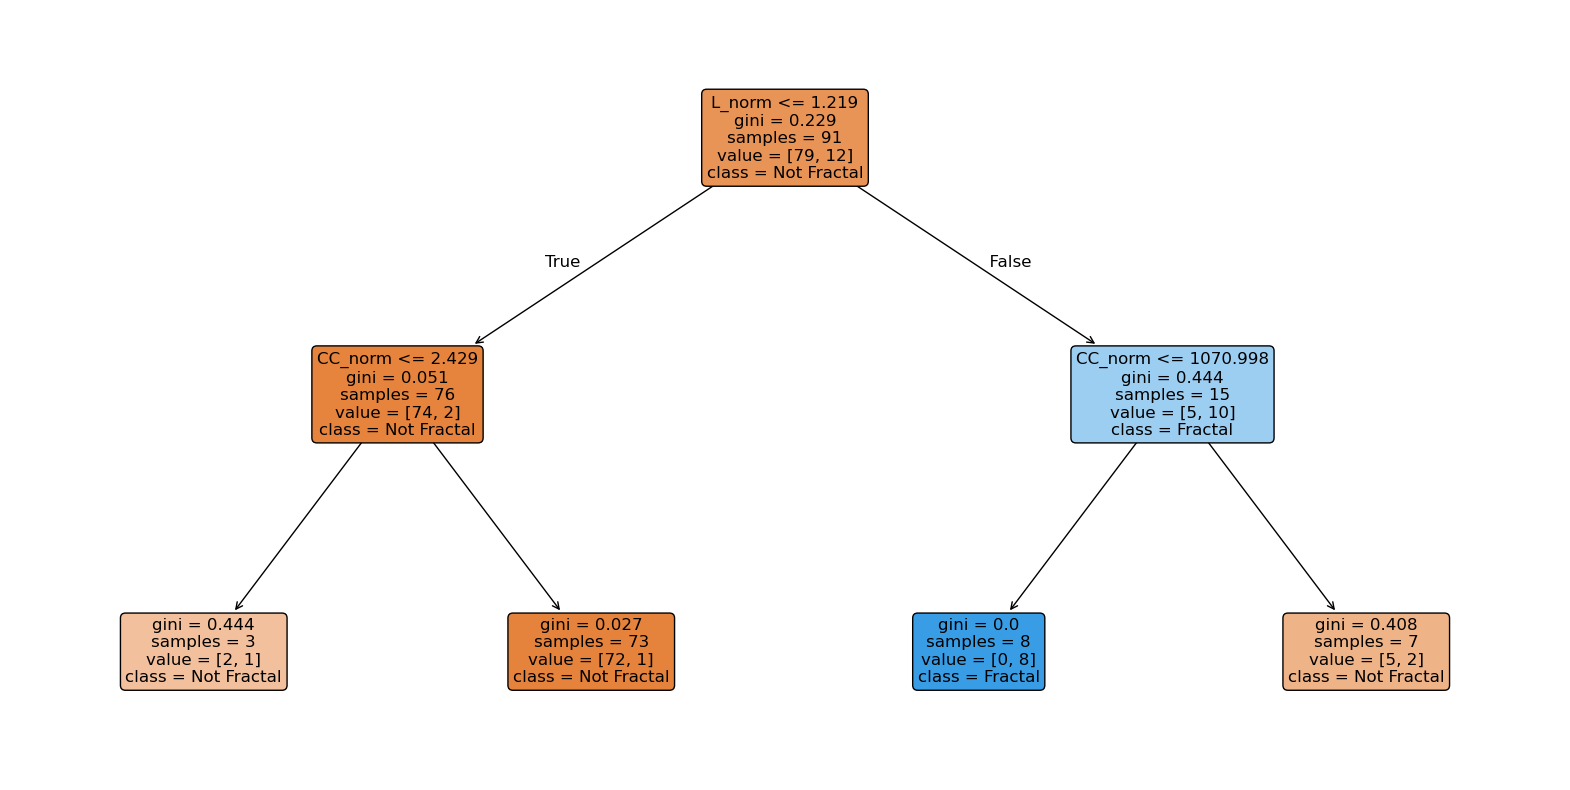

In [30]:
tree_plot(dt_sw_classifier, ['CC_norm', 'L_norm'], (20,10))


In [31]:
def coexistence_scatter(df, l_tree_threshold):
    fig, ax = plt.subplots(figsize=(10, 7))

    non_frac = df[~df['is_fractal']]
    frac = df[df['is_fractal']]

    ax.scatter(
        non_frac['CC_norm'],
        non_frac['L_norm'],
        c='darkorange',
        s=50,
        alpha=0.7,
        edgecolor='white',
        label=f'Non-Fractal (n={len(non_frac)})'
    )
    ax.scatter(
        frac['CC_norm'],
        frac['L_norm'],
        c='darkcyan',
        s=50,
        alpha=0.7,
        edgecolor='white',
        label=f'Fractal (n={len(frac)})'
    )

    ax.set_xscale('log')
    x_lo, x_hi = ax.get_xlim()

    ax.add_patch(Rectangle(
        (CC_NORM_THRESHOLD, L_NORM_LOW),
        x_hi - CC_NORM_THRESHOLD,
        L_NORM_HIGH - L_NORM_LOW,
        facecolor='gold',
        alpha=0.2,
        edgecolor='goldenrod',
        linestyle='--',
        linewidth=1.5,
        label='Small-world region'
    ))
    ax.axhline(
        l_tree_threshold,
        color='indigo',
        linestyle='--',
        linewidth=1.2,
        label='$L_\mathrm{norm} = {%.3f}$' % l_tree_threshold
    )

    ax.set_xlim(x_lo, x_hi)
    ax.set_xlabel('$CC_\mathrm{norm}$')
    ax.set_ylabel('$L_\mathrm{norm}$')
    ax.legend(loc='best')
    plt.show()

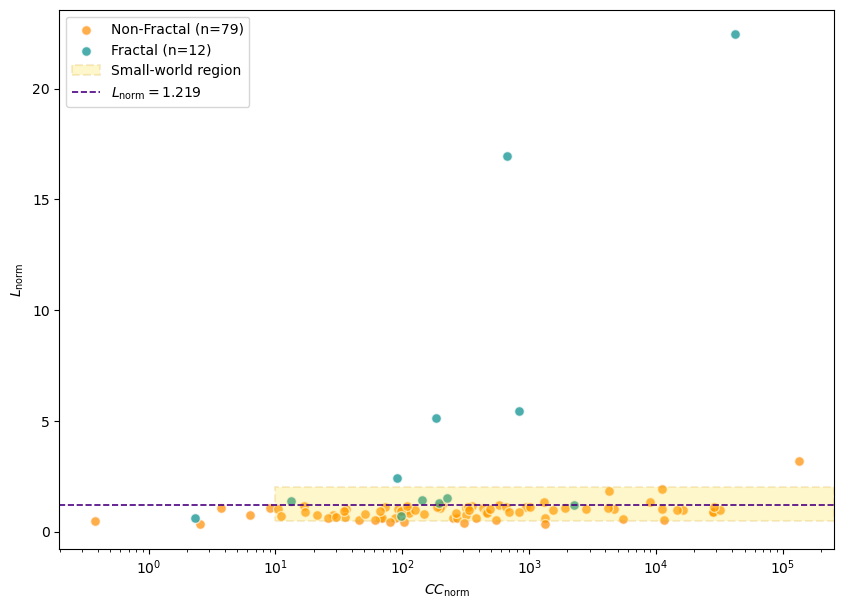

In [32]:
coexistence_scatter(df, dt_sw_classifier.tree_.threshold[0])

# RQ2: Community structure vs fractality

In [33]:
rho_mod, p_mod = stats.spearmanr(df['modularity'], df['d_f'])
print(f'Spearman(modularity, d_f): rho = {rho_mod:.3f}, p = {p_mod:.4g}')

Spearman(modularity, d_f): rho = -0.475, p = 1.91e-06


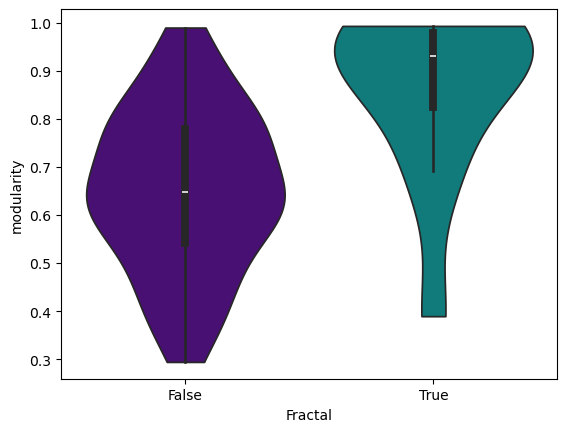

In [34]:
sns.violinplot(
    data=df, x='is_fractal', y='modularity',
    hue='is_fractal',
    palette={False: 'indigo', True: 'darkcyan'},
    inner='box', 
    legend=False,
    cut=0
)
plt.xlabel('Fractal')
plt.ylabel('modularity')
plt.show()

In [35]:
df[df['modularity'] > 1]

,name,is_mst,modularity,small_world,hcs_std,hcs_mean,assortativity,variance,fit_pl,fit_exp,wmse_pl,wmse_exp,pl_ex_ratio,CC_norm,L_norm,V,E,d_f,is_fractal


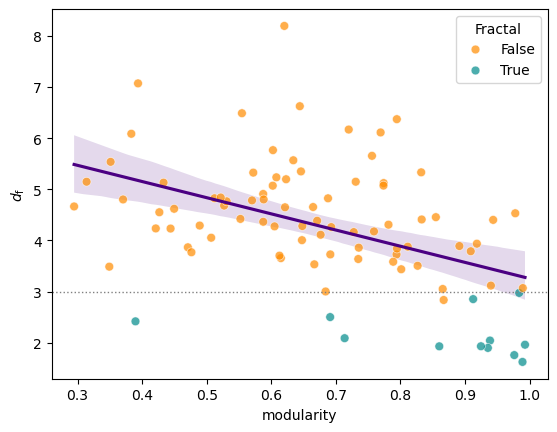

In [36]:
sns.regplot(
    data=df, 
    x='modularity', 
    y='d_f',
    scatter=False,
    line_kws={'color': 'indigo'}
)
sns.scatterplot(
    data=df, 
    x='modularity', 
    y='d_f',
    hue='is_fractal',
    palette={True: 'darkcyan', False: 'darkorange'},
    s=40, 
    alpha=0.7, 
    edgecolor='white'
)
plt.axhline(D_F_THRESHOLD, color='gray', linestyle=':', linewidth=1)
plt.xlabel('modularity')
plt.ylabel('$d_\mathrm{f}$')
plt.legend(title='Fractal')
plt.show()

# RQ3: Assortativity and hub repulsion vs fractality

In [37]:
rho_a, p_a = stats.spearmanr(df['assortativity'], df['d_f'])
rho_h, p_h = stats.spearmanr(df['hcs_mean'], df['d_f'])

print(f'Spearman(assortativity, d_f): rho = {rho_a:.3f}, p = {p_a:.4g}')
print(f'Spearman(hcs_mean, d_f)     : rho = {rho_h:.3f}, p = {p_h:.4g}')

Spearman(assortativity, d_f): rho = -0.316, p = 0.002299
Spearman(hcs_mean, d_f)     : rho = 0.388, p = 0.0001456


In [38]:
def assortativity_hcs_scatter(df):
    fig, ax = plt.subplots(figsize=(10, 7))

    non_frac = df[~df['is_fractal']]
    frac = df[df['is_fractal']]

    ax.scatter(
        non_frac['assortativity'],
        non_frac['hcs_mean'],
        c='darkorange',
        s=50,
        alpha=0.7,
        edgecolor='white',
        label=f'Non-Fractal (n={len(non_frac)})'
    )
    ax.scatter(
        frac['assortativity'],
        frac['hcs_mean'],
        c='darkcyan',
        s=50,
        alpha=0.7,
        edgecolor='white',
        label=f'Fractal (n={len(frac)})'
    )

    ax.axvline(
        0,
        color='gray',
        linestyle=':',
        linewidth=1,
        label='assortativity = 0'
    )

    ax.set_xlabel('assortativity')
    ax.set_ylabel('HCS')
    ax.set_yscale('linear')
    ax.legend(loc='best')
    plt.show()

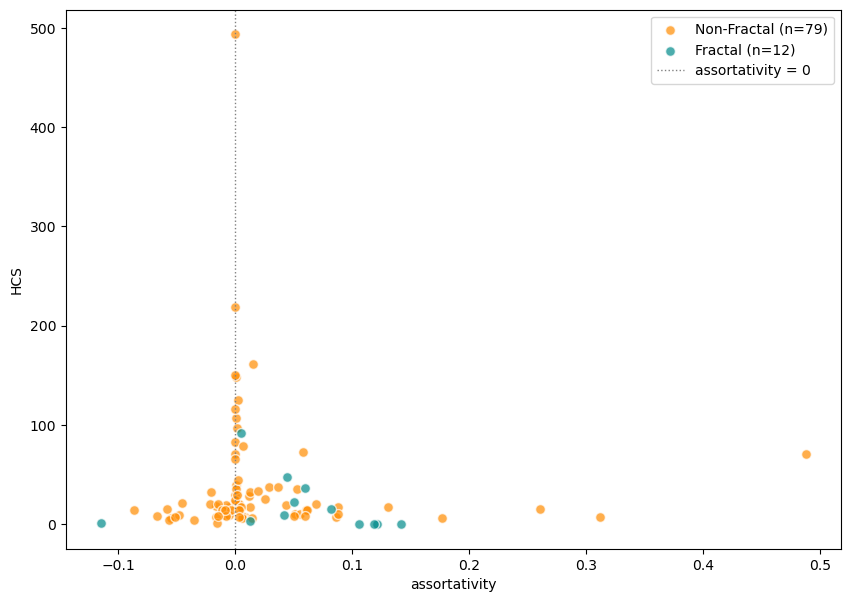

In [39]:
assortativity_hcs_scatter(df)

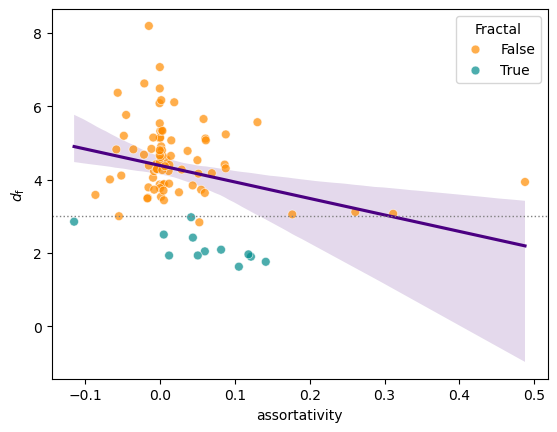

In [40]:
sns.regplot(
    data=df, 
    x='assortativity', 
    y='d_f',
    scatter=False,
    line_kws={'color': 'indigo'}
)
sns.scatterplot(
    data=df, 
    x='assortativity', 
    y='d_f',
    hue='is_fractal',
    palette={True: 'darkcyan', False: 'darkorange'},
    s=40, 
    alpha=0.7, 
    edgecolor='white'
)
plt.axhline(D_F_THRESHOLD, color='gray', linestyle=':', linewidth=1)
plt.xlabel('assortativity')
plt.ylabel('$d_\mathrm{f}$')
plt.legend(title='Fractal')
plt.show()

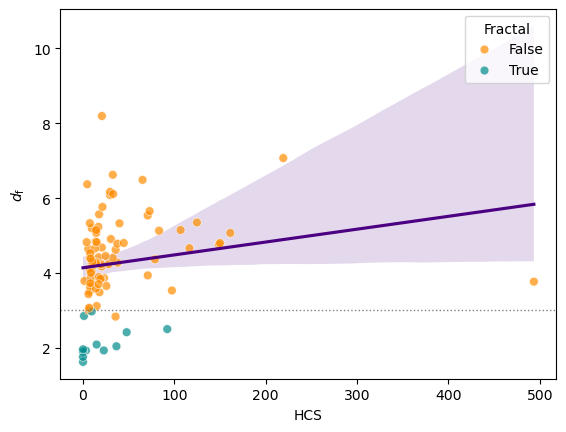

In [41]:
sns.regplot(
    data=df, 
    x='hcs_mean', 
    y='d_f',
    scatter=False,
    line_kws={'color': 'indigo'}
)
sns.scatterplot(
    data=df, 
    x='hcs_mean', 
    y='d_f',
    hue='is_fractal',
    palette={True: 'darkcyan', False: 'darkorange'},
    s=40, 
    alpha=0.7, 
    edgecolor='white'
)
plt.axhline(D_F_THRESHOLD, color='gray', linestyle=':', linewidth=1)
plt.xlabel('HCS')
plt.ylabel('$d_\mathrm{f}$')
plt.legend(title='Fractal')
plt.show()

# RQ4: MST extraction effect on fractality

In [42]:
paired_df = pd.merge(
    df[['name', 'd_f', 'pl_ex_ratio', 'is_fractal']],
    mst_df[['name', 'd_f', 'pl_ex_ratio', 'is_fractal']],
    on='name',
    how='inner',
    suffixes=('_gc', '_mst')
)

print(f'Size: {len(paired_df)}')
print(f'Fractal GC: ', len(paired_df[paired_df['is_fractal_gc']]))
print('Fractal MST: ', len(paired_df[paired_df['is_fractal_mst']]))

Size: 29
Fractal GC:  6
Fractal MST:  23


In [43]:
w_stat, w_p = stats.wilcoxon(paired_df['d_f_gc'], paired_df['d_f_mst'])

print(f'Wilcoxon: W = {w_stat:.1f}, p = {w_p:.4g}')
print(f'Median d_f - GC : {paired_df["d_f_gc"].median():.3f}')
print(f'Median d_f - MST: {paired_df["d_f_mst"].median():.3f}')

Wilcoxon: W = 0.0, p = 3.725e-09
Median d_f - GC : 4.176
Median d_f - MST: 2.351


In [44]:
def mst_skeleton_scatter(paired_df):
    def edge_colors(sub):
        return np.where(sub['is_fractal_mst'], 'indigo', 'gold')

    fig, ax = plt.subplots(figsize=(8, 8))

    non_frac = paired_df[~paired_df['is_fractal_gc']]
    frac = paired_df[paired_df['is_fractal_gc']]

    ax.scatter(
        non_frac['d_f_gc'],
        non_frac['d_f_mst'],
        s=90,
        alpha=0.75,
        c='darkorange',
        edgecolor=edge_colors(non_frac),
        linewidths=3,
        label=f'GC Non-Fractal (n={len(non_frac)})'
    )

    ax.scatter(
        frac['d_f_gc'],
        frac['d_f_mst'],
        s=90,
        alpha=0.75,
        c='darkcyan',
        edgecolor=edge_colors(frac),
        linewidths=3,
        label=f'GC Fractal (n={len(frac)})'
    )

    lo = min(paired_df['d_f_gc'].min(), paired_df['d_f_mst'].min()) - 0.2
    hi = max(paired_df['d_f_gc'].max(), paired_df['d_f_mst'].max()) + 0.2

    ax.axvline(D_F_THRESHOLD, color='gray', linestyle=':', linewidth=1)
    ax.axhline(D_F_THRESHOLD, color='gray', linestyle=':', linewidth=1)
    ax.plot([lo, hi], [lo, hi], color='gray', linestyle=':', linewidth=1)

    mst_legend = [
        Line2D(
            [0], [0], 
            marker='o', 
            linestyle='',
            markerfacecolor='None', 
            markeredgecolor='indigo',
            markeredgewidth=2, 
            markersize=10, 
            label='MST Fractal'
        ),
        Line2D(
            [0], [0], 
            marker='o', 
            linestyle='',
            markerfacecolor='None', 
            markeredgecolor='gold',
            markeredgewidth=2, 
            markersize=10, 
            label='MST Non-Fractal'
        ),
                Line2D(
            [0], [0], 
            marker='o', 
            linestyle='',
            markerfacecolor='darkcyan', 
            markeredgecolor='None',
            # markeredgewidth=2, 
            markersize=10, 
            label='GC Fractal'
        ),
        Line2D(
            [0], [0], 
            marker='o', 
            linestyle='',
            markerfacecolor='darkorange', 
            markeredgecolor='None',
            # markeredgewidth=2, 
            markersize=10, 
            label='GC Non-Fractal'
        ),
    ]

    ax.legend(handles=mst_legend, loc='upper left')

    ax.set_xlim(lo, hi)
    ax.set_ylim(lo, hi)
    ax.set_xlabel('$d_\mathrm{f}$ - Giant Component')
    ax.set_ylabel('$d_\mathrm{f}$ - Maximum Spanning Tree')
    plt.show()

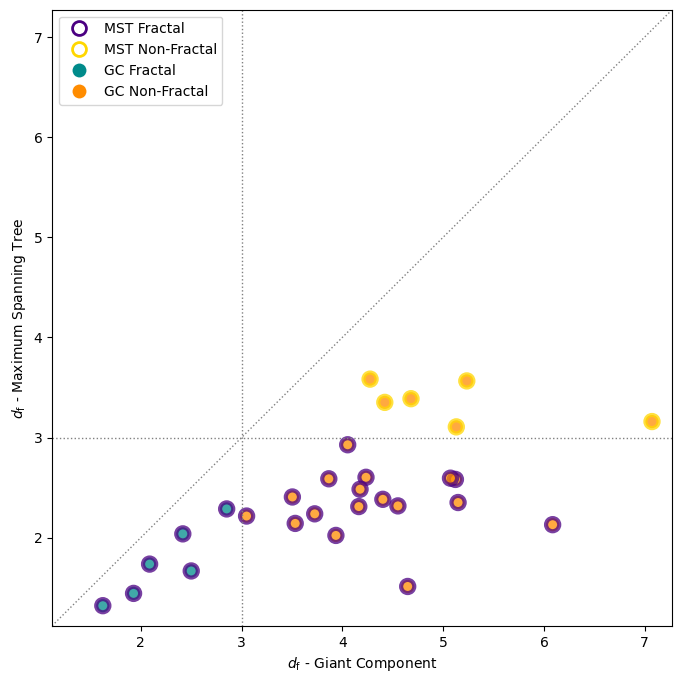

In [45]:
mst_skeleton_scatter(paired_df)

## Exploratory Multivariate Analysis: Decision Tree

In [46]:
X_clas = df[feature_cols]
y_clas = df[target_col_clas]

In [47]:
# Train Decision Tree
dt_classifier = DecisionTreeClassifier(random_state=42, max_depth=3, class_weight='balanced')
dt_classifier.fit(X_clas, y_clas)

DecisionTreeClassifier(class_weight='balanced', max_depth=3, random_state=42)

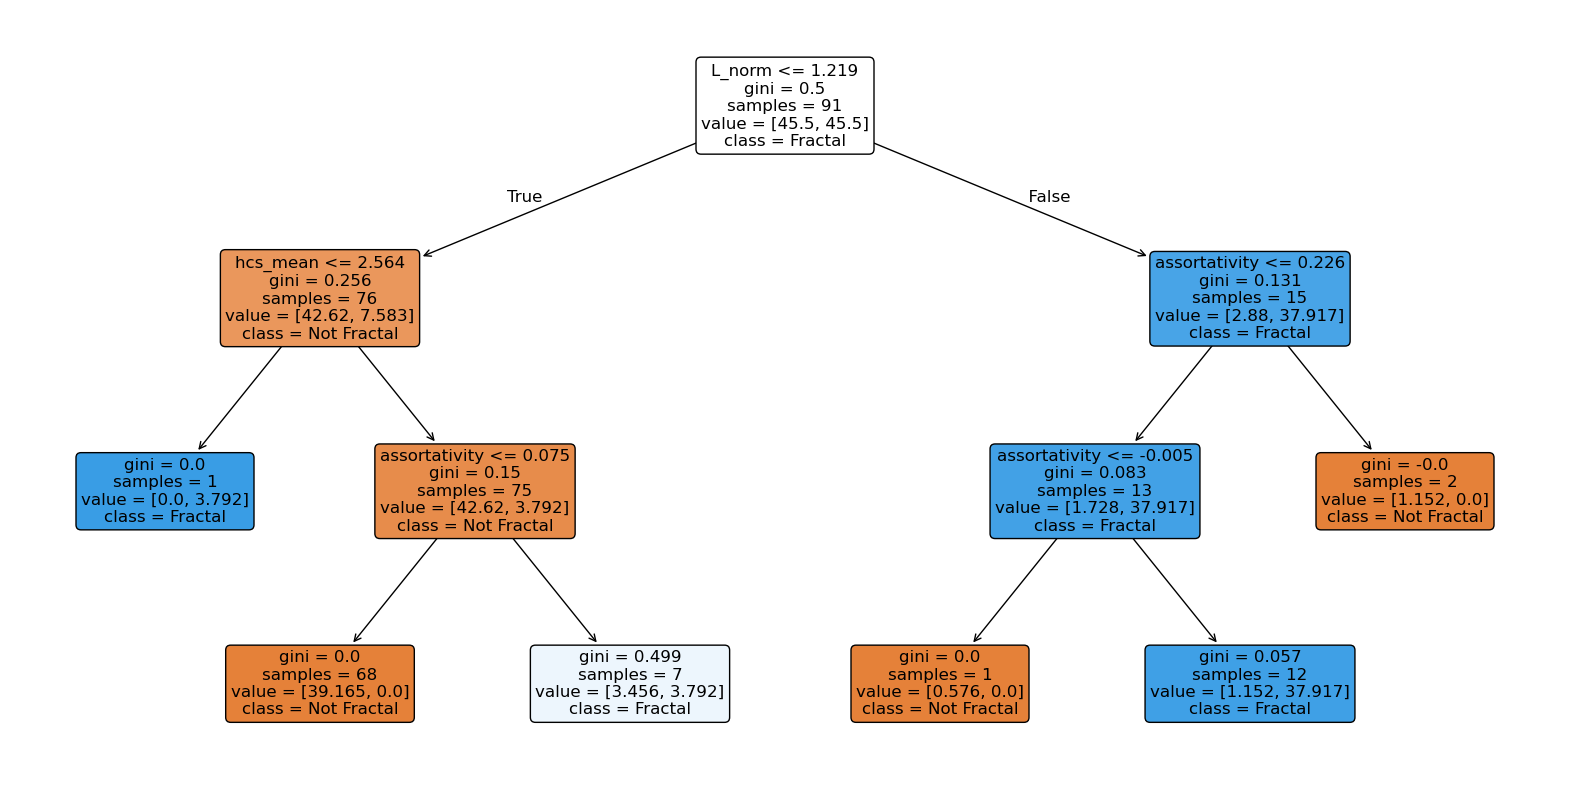

In [48]:
tree_plot(dt_classifier, feature_cols, (20, 10))

In [49]:
dt_classifier_simple = DecisionTreeClassifier(random_state=42, max_depth=3)
dt_classifier_simple.fit(X_clas, y_clas)

DecisionTreeClassifier(max_depth=3, random_state=42)

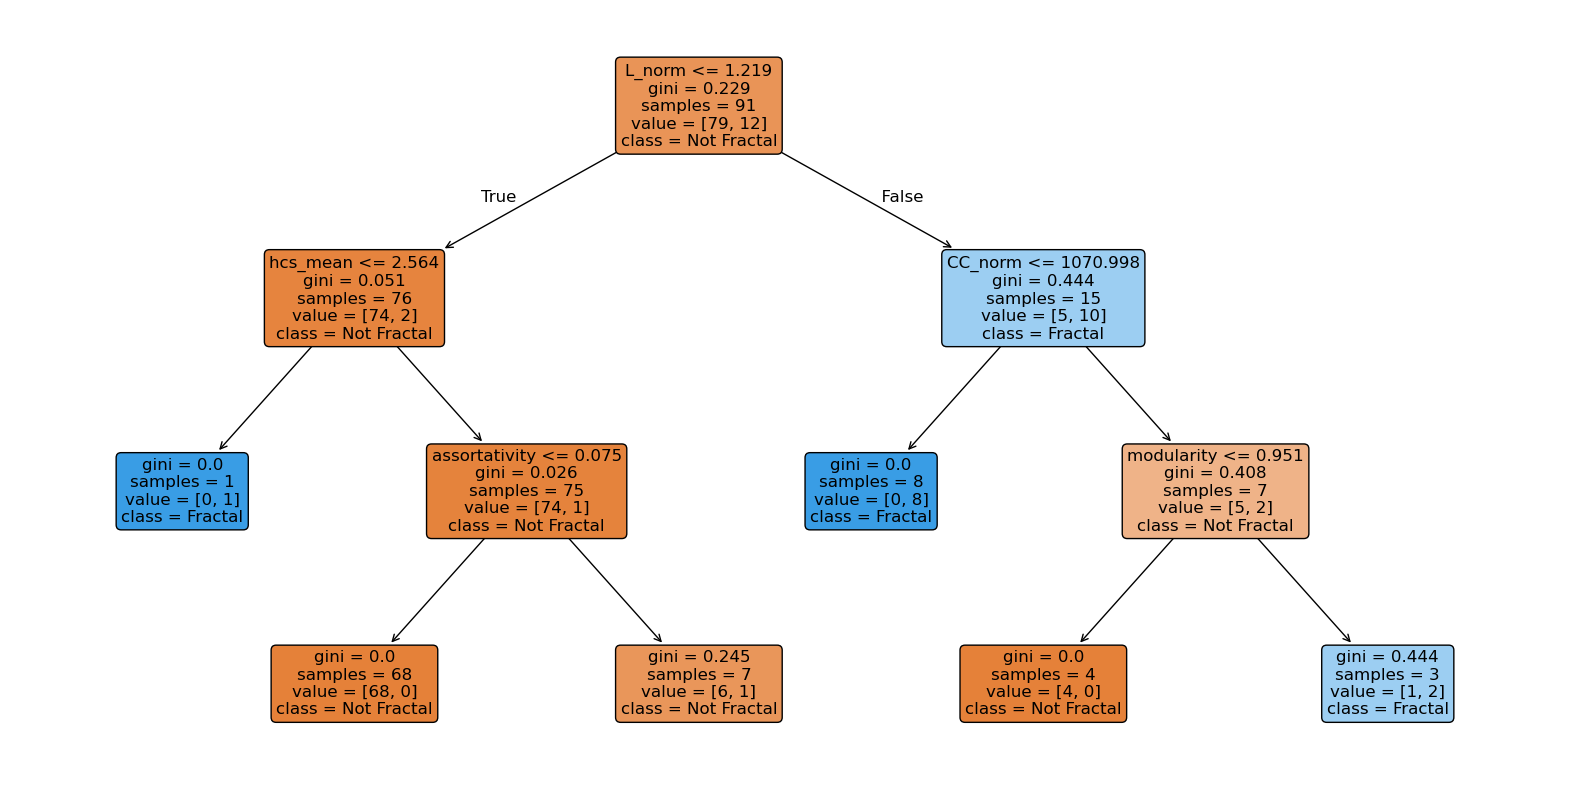

In [50]:
tree_plot(dt_classifier_simple, feature_cols, (20,10))

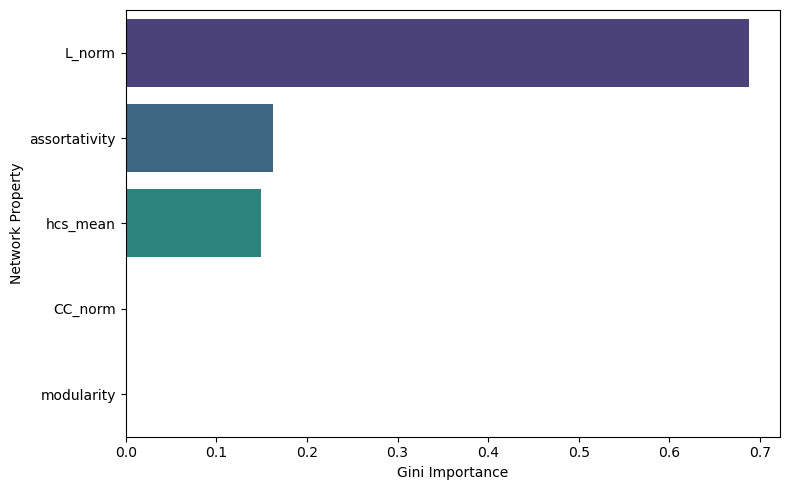

In [51]:
importance_df = pd.DataFrame({
    'Feature': feature_cols,
    'Importance': dt_classifier.feature_importances_
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(x='Importance', y='Feature', data=importance_df, palette='viridis', hue='Feature', legend=False)
plt.xlabel('Gini Importance')
plt.ylabel('Network Property')
plt.tight_layout()
plt.show()

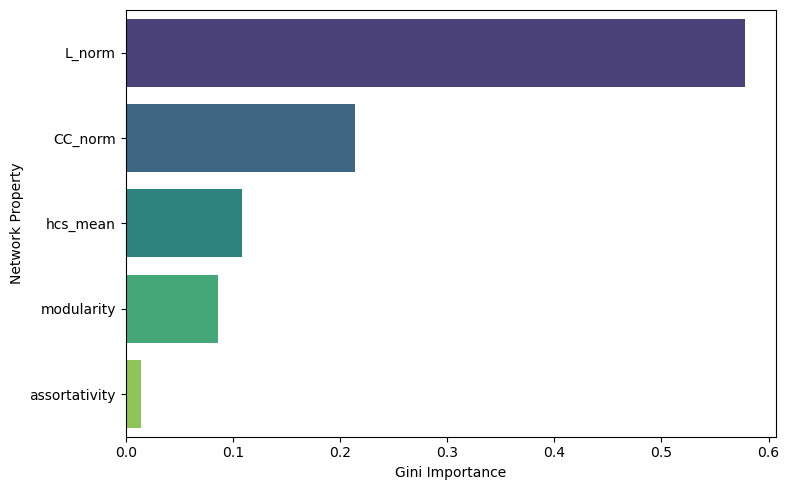

In [52]:
importance_df_simple = pd.DataFrame({
    'Feature': feature_cols,
    'Importance': dt_classifier_simple.feature_importances_
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(x='Importance', y='Feature', data=importance_df_simple, palette='viridis', hue='Feature', legend=False)
plt.xlabel('Gini Importance')
plt.ylabel('Network Property')
plt.tight_layout()
plt.show()